In [3]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")
print("Rows and columns:", df.shape)
print(df.head())

Rows and columns: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
blank_charges = df["TotalCharges"].astype(str).str.strip().eq("")

print("Number of rows with blank TotalCharges:", blank_charges.sum())
df.loc[blank_charges, ["customerID","tenure","MonthlyCharges","TotalCharges","Churn"]]

Number of rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors="coerce")
df.loc[blank_charges & (df["tenure"] == 0),"TotalCharges"] = 0

print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isna().sum())
print(df["Churn"].value_counts())

float64
0
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [7]:
pd.crosstab(df["Contract"],df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [8]:
pd.crosstab(df["Contract"],df["Churn"],normalize="index").mul(100).round(1)

Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


In [9]:
df.groupby("Churn")["tenure"].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

In [10]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, float("inf")],
    labels=["0–12 months", "13–24 months", "25–48 months", "49+ months"],
)
df["tenure_group"].value_counts().sort_index()

tenure_group
0–12 months     2186
13–24 months    1024
25–48 months    1594
49+ months      2239
Name: count, dtype: int64

In [11]:
pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
).mul(100).round(1)

Churn,No,Yes
tenure_group,,
0–12 months,52.6,47.4
13–24 months,71.3,28.7
25–48 months,79.6,20.4
49+ months,90.5,9.5


In [12]:
pd.crosstab(
    [df["tenure_group"], df["Contract"]],
    df["Churn"],
    normalize="index"
).mul(100).round(1)

Churn                           No   Yes
tenure_group Contract                   
0–12 months  Month-to-month   48.6  51.4
             One year         89.5  10.5
             Two year        100.0   0.0
13–24 months Month-to-month   62.3  37.7
             One year         91.9   8.1
             Two year        100.0   0.0
25–48 months Month-to-month   67.1  32.9
             One year         89.4  10.6
             Two year         97.8   2.2
49+ months   Month-to-month   74.0  26.0
             One year         87.1  12.9
             Two year         96.7   3.3

In [13]:
pd.crosstab(df["tenure_group"], df["Contract"])

Contract,Month-to-month,One year,Two year
tenure_group,,,
0–12 months,1994,124,68
13–24 months,737,197,90
25–48 months,802,518,274
49+ months,342,634,1263


In [14]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
).mul(100).round(1)

Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


In [15]:
fiber = df[df["InternetService"] == "Fiber optic"]
fiber.groupby("Churn")["MonthlyCharges"].median()

Churn
No     94.80
Yes    87.55
Name: MonthlyCharges, dtype: float64

In [16]:
pd.crosstab(
    fiber["TechSupport"],
    fiber["Churn"],
    normalize="index"
).mul(100).round(1)

Churn,No,Yes
TechSupport,,
No,50.6,49.4
Yes,77.4,22.6


In [17]:
segment = df[
    (df["InternetService"] == "Fiber optic") &
    (df["Contract"] == "Month-to-month") &
    (df["TechSupport"] == "No")
]

print("Customers in segment:", len(segment))
print("Churn rate (%):", round(segment["Churn"].eq("Yes").mean() * 100, 1))

Customers in segment: 1796
Churn rate (%): 57.5


In [18]:
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())
print("Missing values in dataset:", df.isna().sum().sum())

Duplicate customer IDs: 0
Missing values in dataset: 0


In [19]:
X = df.drop(columns=["customerID", "Churn","tenure_group"])
y = df["Churn"].map({"Yes": 1, "No": 0})

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (7043, 19)
y shape: (7043,)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training customers:", len(X_train))
print("Test customers:", len(X_test))

Training customers: 5634
Test customers: 1409


In [23]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(include="number").columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\ASMI\AppData\Local\Temp\ipykernel_17632\3165000937.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


In [24]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

print("Encoded training shape:", X_train_cat.shape)
print("Encoded test shape:", X_test_cat.shape)

Encoded training shape: (5634, 41)
Encoded test shape: (1409, 41)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

print("Scaled training shape:", X_train_num.shape)
print("Scaled test shape:", X_test_num.shape)

Scaled training shape: (5634, 4)
Scaled test shape: (1409, 4)


In [26]:
import numpy as np

X_train_ready = np.hstack([X_train_cat, X_train_num])
X_test_ready = np.hstack([X_test_cat, X_test_num])

print("Ready training shape:", X_train_ready.shape)
print("Ready test shape:", X_test_ready.shape)

Ready training shape: (5634, 45)
Ready test shape: (1409, 45)


In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(X_train_ready, y_train)

print("Training accuracy:", round(model.score(X_train_ready, y_train) * 100, 1))
print("Test accuracy:", round(model.score(X_test_ready, y_test) * 100, 1))

Training accuracy: 80.6
Test accuracy: 80.6


In [28]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test_ready)

print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

[[926 109]
 [165 209]]


In [29]:
y_prob = model.predict_proba(X_test_ready)[:, 1]

print(y_prob[:10])

[0.04591993 0.68371345 0.05893985 0.40183529 0.02142426 0.60297803
 0.44762898 0.13033554 0.00280355 0.39473874]


In [30]:
test_results = df.loc[
    X_test.index,
    ["customerID", "MonthlyCharges"]
].copy()

test_results["actual_churn"] = y_test
test_results["churn_probability"] = y_prob

test_results.sort_values(
    "churn_probability", ascending=False
).head(10)

,customerID,MonthlyCharges,actual_churn,churn_probability
3380,5178-LMXOP,95.10,1,0.854280
6866,0295-PPHDO,95.45,1,0.831583
2631,6861-XWTWQ,99.25,1,0.828147
6365,8884-ADFVN,101.95,1,0.821692
4585,1069-XAIEM,85.05,1,0.818493
2797,6023-YEBUP,100.95,1,0.817586
3346,2545-EBUPK,84.05,0,0.817334
3727,9057-SIHCH,96.60,1,0.817042
6894,1400-MMYXY,105.90,1,0.815703
935,6630-UJZMY,83.25,0,0.811504


In [31]:
from scipy.stats import chi2_contingency

contract_counts = pd.crosstab(df["Contract"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(contract_counts)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Smallest expected count:", expected.min())

Chi-square statistic: 1184.5965720837926
P-value: 5.863038300673391e-258
Smallest expected count: 390.889819679114


In [32]:
n = contract_counts.to_numpy().sum()
smaller_dimension = min(contract_counts.shape) - 1

cramers_v = (chi2 / (n * smaller_dimension)) ** 0.5

print("Cramér's V:", round(cramers_v, 3))

Cramér's V: 0.41


In [36]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, ttest_ind
from statsmodels.stats.multitest import multipletests

df["churn_flag"] = df["Churn"].map({"No": 0, "Yes": 1})

results = []

# Tests for categorical attributes
for column in ["Contract", "InternetService", "TechSupport", "SeniorCitizen"]:
    table = pd.crosstab(df[column], df["Churn"])
    statistic, p, dof, expected = chi2_contingency(table)
    v = np.sqrt(
        statistic / (table.to_numpy().sum() * (min(table.shape) - 1))
    )

    results.append({
        "attribute": column,
        "test": "Chi-square",
        "p_value": p,
        "cramers_v": v,
        "minimum_expected_count": expected.min()
    })

# Tests for numerical attributes
for column in ["MonthlyCharges", "tenure"]:
    left = df.loc[df["Churn"] == "Yes", column]
    stayed = df.loc[df["Churn"] == "No", column]

    test = ttest_ind(left, stayed, equal_var=False)
    ci = test.confidence_interval(confidence_level=0.95)

    results.append({
        "attribute": column,
        "test": "Welch t-test",
        "p_value": test.pvalue,
        "mean_churned": left.mean(),
        "mean_stayed": stayed.mean(),
        "mean_difference": left.mean() - stayed.mean(),
        "difference_ci_low": ci.low,
        "difference_ci_high": ci.high
    })

stats_results = pd.DataFrame(results)
stats_results["adjusted_p_value"] = multipletests(
    stats_results["p_value"], method="holm"
)[1]
stats_results["significant_at_0.05"] = (
    stats_results["adjusted_p_value"] < 0.05
)

display(stats_results)

,attribute,test,p_value,cramers_v,minimum_expected_count,mean_churned,mean_stayed,mean_difference,difference_ci_low,difference_ci_high,adjusted_p_value,significant_at_0.05
0,Contract,Chi-square,5.863038e-258,0.410116,390.889820,NaN,NaN,NaN,NaN,NaN,3.517823e-257,True
1,InternetService,Chi-square,9.571788e-160,0.322455,404.954423,NaN,NaN,NaN,NaN,NaN,2.871536e-159,True
2,TechSupport,Chi-square,1.443084e-180,0.342916,404.954423,NaN,NaN,NaN,NaN,NaN,5.772336e-180,True
3,SeniorCitizen,Chi-square,1.510067e-36,0.150453,303.052392,NaN,NaN,NaN,NaN,NaN,1.510067e-36,True
4,MonthlyCharges,Welch t-test,8.592449e-73,NaN,NaN,74.441332,61.265124,13.176209,11.772845,14.579572,1.718490e-72,True
5,tenure,Welch t-test,1.195495e-232,NaN,NaN,17.979133,37.569965,-19.590832,-20.693778,-18.487885,5.977473e-232,True


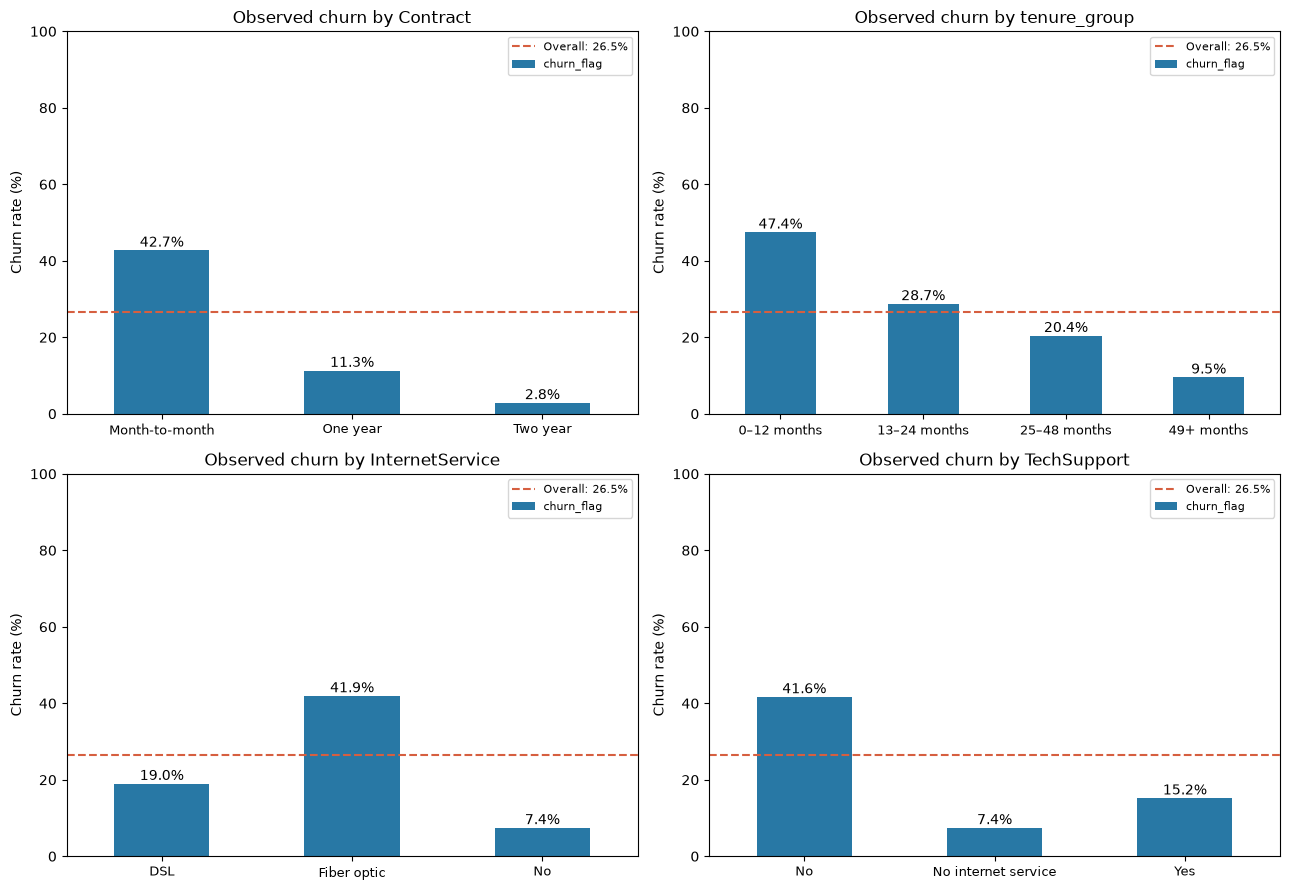

In [37]:
import matplotlib.pyplot as plt
from pathlib import Path

output = Path("churn_project_outputs")
output.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
overall_rate = df["churn_flag"].mean() * 100

columns = ["Contract", "tenure_group", "InternetService", "TechSupport"]

for column, ax in zip(columns, axes.flat):
    rates = (
        df.groupby(column, observed=True)["churn_flag"].mean() * 100
    )

    rates.plot.bar(ax=ax, color="#2878A5", rot=0)
    ax.axhline(
        overall_rate, color="#D65F40", linestyle="--",
        label=f"Overall: {overall_rate:.1f}%"
    )

    for position, rate in enumerate(rates):
        ax.text(position, rate + 1, f"{rate:.1f}%", ha="center")

    ax.set_title(f"Observed churn by {column}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", labelsize=9)
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(output / "churn_summary_charts.png", dpi=200)
plt.show()

In [38]:
segments = (
    df.groupby(["Contract", "tenure_group"], observed=True)["churn_flag"]
      .agg(
          customers="size",
          churned="sum",
          observed_churn_rate="mean"
      )
      .reset_index()
)

# Use the overall rate if a segment has fewer than 30 customers
segments["risk_proxy"] = segments["observed_churn_rate"].where(
    segments["customers"] >= 30,
    df["churn_flag"].mean()
)

# Only customers who have not already churned are eligible
active_customers = df.loc[df["Churn"] == "No"].copy()

ranked_targets = active_customers.merge(
    segments,
    on=["Contract", "tenure_group"],
    how="left",
    validate="many_to_one"
)

ranked_targets["priority_score"] = (
    ranked_targets["risk_proxy"] * ranked_targets["MonthlyCharges"]
)

ranked_targets = ranked_targets.sort_values(
    ["priority_score", "customerID"],
    ascending=[False, True]
).reset_index(drop=True)

ranked_targets["priority_rank"] = ranked_targets.index + 1

# Illustrative budget assumptions, in the dataset's monetary units
budget = 1000
cost_per_contact = 10
capacity = int(budget // cost_per_contact)
selected_targets = ranked_targets.head(capacity).copy()

display(selected_targets[[
    "priority_rank", "customerID", "Contract", "tenure_group",
    "MonthlyCharges", "customers", "risk_proxy", "priority_score"
]].head(10))

print("Current customers ranked:", len(ranked_targets))
print("Customers selected:", len(selected_targets))
print("Assumed campaign cost:", len(selected_targets) * cost_per_contact)
print(
    "Selected customers' monthly charges:",
    round(selected_targets["MonthlyCharges"].sum(), 2)
)

,priority_rank,customerID,Contract,tenure_group,MonthlyCharges,customers,risk_proxy,priority_score
0,1,3292-PBZEJ,Month-to-month,0–12 months,111.40,1994,0.513541,57.208425
1,2,2081-VEYEH,Month-to-month,0–12 months,107.95,1994,0.513541,55.436710
2,3,5760-IFJOZ,Month-to-month,0–12 months,107.95,1994,0.513541,55.436710
3,4,6734-GMPVK,Month-to-month,0–12 months,105.30,1994,0.513541,54.075827
4,5,7145-FEJWU,Month-to-month,0–12 months,105.30,1994,0.513541,54.075827
5,6,2018-PZKMU,Month-to-month,0–12 months,103.10,1994,0.513541,52.946038
6,7,9547-ITEFG,Month-to-month,0–12 months,102.60,1994,0.513541,52.689268
7,8,8118-TJAFG,Month-to-month,0–12 months,101.50,1994,0.513541,52.124373
8,9,4132-KALRO,Month-to-month,0–12 months,100.85,1994,0.513541,51.790572
9,10,0722-SVSFK,Month-to-month,0–12 months,100.40,1994,0.513541,51.559478


Current customers ranked: 5174
Customers selected: 100
Assumed campaign cost: 1000
Selected customers' monthly charges: 9128.75
